<a href="https://colab.research.google.com/github/hyperdbio/Android-inject/blob/master/ex03_%EB%8B%A4%EC%A4%91%EB%B6%84%EB%A5%98_iris%EB%8D%B0%EC%9D%B4%ED%84%B0%ED%99%9C%EC%9A%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ex03_다중분류_iris데이터활용분류.ipynb

### 회귀, 이진, 다중 분류 설정값
1. 회귀 출력층, 오차공식
  - 출력층 units=1, activation='linear'
  - activation 값은 units값이랑 동일(생략가능)
  - 오차공식 loss'mse' (평균제곱오차)
  - 평가지표 metrics=['mse'] (생략가능)

2. 이진분류 출력층, 오차공식
  - 출력층 units = 1, activation='sigmoid'
  - 유닛 1개에서 결과 나오면, sigmoid함수와 연결되어 0~1 확률값으로 마지막 최종 출력결과를 확인할 수 있음
  - 0.5 크면 1, 0.5 작으면 0
  - 오차공식 loss='binary_crossentropy'
  - 평가지표 metrics=['accuracy']

3. 다중분류(0,1,2) 출력층, 오차공식
  - 답 데이터에 대한 전처리: 답데이터를 0과 1로 표현하는 인코딩이 필요(one-hot encoding)
  - 출력층 units=클래스의 수,
  activation='softmax'
  - softmax : 모든 클래스 예측의 확률값을 더했을 때, 총합이 1이 되게 만드는 것. 각각의 클래스의 확률에서 어떤 확률이 제일 커서 어떤 클래스로 예측된 것인지 비교가 용이하게 함.
  - 오차공식 loss='categorical_crossentropy'
  - 평가지표 metrics=['accuracy']



## 목표
 - iris데이터 활용해서 붓꽃 품종 분류해보자
  - 품종 : 3가지 ( 클래스 : 3개)
- 신경망에서 다중분류 학습 진행해보자


In [ ]:
# 환경설정
# cpu
# sklearn.datasets -> 드라이브 연동x

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris


In [ ]:
# 데이터 살펴보기
data = load_iris()
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [ ]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
# data: 특성(문제, 독립변수, 피처, feature, X)
# target: 타겟(답, 종속변수, label, 라벨, 레이블, y)
# feature_names: 특성의 이름(data 안에 array 배열이기 때문에, 컬럼명 설명이 안되어 있어 해당 키워드로 확인)
# target_names: 답의 실제 이름(문자열로 설명해줌, target은 숫자로 표현되어 있음)
# -- index 개념을 매칭해서 의미 파악
# DESCR : describe 기술통계량, 데이터에 대한 설명



In [ ]:
# data 키워드 접근해서 value 확인하기
data.data.shape

# 150개 행, 4개 열
# 특성의 개수 : 4개
# 특성 이름 확인
data.feature_names

# ['sepal length (cm)', : 꽃받침 길이
#  'sepal width (cm)',  : 꽃받침 너비
#  'petal length (cm)', : 꽃잎 길이
#  'petal width (cm)']  : 꽃잎 너비

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [ ]:
# 답 데이터 살펴보기
pd.Series(data.target).value_counts()

# 데이터가 다양성을 유지하며 정리되어 있음
# 답 이름 살펴보기
data.target_names[2]

# target_names 인덱스번호를 기준으로 target 과 매칭하여 실제 품종의 이름을 확인할 수 있음

np.str_('virginica')

In [ ]:
data.target_names

# 알파벳 순서 기준

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

### 데이터 분리
 - 문제와 답: 각 변수에 담아주기(X,y)
 - 훈련셋과 테스트셋: train_test_split()
   - 8:2
   - 3
   - 1) 랜덤 섞기   2) 크기에 따라 분할 => 랜덤샘플링

In [ ]:
X = data.data
y = data.target

print(X.shape, y.shape)

(150, 4) (150,)


In [ ]:
# 행 분리
# train.test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=3)
# 크기확인
print('훈련셋:', X_train.shape, y_train.shape)
print('테스트셋:', X_test.shape, y_test.shape)

훈련셋: (120, 4) (120,)
테스트셋: (30, 4) (30,)


### 답데이터 인코딩
 - 원핫인코딩
 - pd.get_dummies(대상) -> pd 자료구조
 - to.categorical(대상) -> np 자료구조

In [ ]:
# 각 클래스의 의미하는 바를 1로 맞춰서 오차를 쉽게 계산하고 비교할 수 있게 함
type(pd.get_dummies(y_train)) # pandas.core.frame.DataFrame
from tensorflow.keras.utils import to_categorical
type(to_categorical(y_train)) #numpy.ndarray

numpy.ndarray

In [ ]:
y_train_oh = to_categorical(y_train)
y_test_oh = to_categorical(y_test)
print(y_train_oh.shape)
print(y_test_oh.shape)

(120, 3)
(30, 3)


In [ ]:
# 입력층 연결될 특성 개수
n_features = X_train.shape[1]
n_features
# 출력층 연결될 클래스의 개수
n_class = y_train_oh.shape[1]

print('-특성의 개수:', n_features)
print('-클래스의 개수:', n_class)

-특성의 개수: 4
-클래스의 개수: 3


### keras활용 신경망 생성!
- 1. 신경망 구조 설계
- 2. 학습/평가 방법 설정
- 3. 학습 및 시각화
- 4. 모델 평가 및 예측

In [ ]:
# 뼈대 구축 하는 도구 불러오기
from tensorflow.keras import Sequential
# 층 내용 정의
from tensorflow.keras.layers import Dense

In [ ]:
# 1. 신경망 뼈대 구축
model = Sequential()

# 2. 입력층 + 중간층 1
model.add(Dense(16, input_dim=n_features, activation='relu'))

#  중간층 2,3
model.add(Dense(32, activation='relu'))
model.add(Dense(10, activation='relu'))

# 출력층
# units = 클래스의 수
# 활성화 함수 = 예측결과 총 합이 1이 되어, 비교가 쉽게 만드는 정규화 내용이 포함된 함수로 연결 'softmax'
model.add(Dense(n_class, activation='softmax'))

# 모델 정보 요약
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 987 (3.86 KB)

 Trainable params: 987 (3.86 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 2. 모델 학습 / 평가 방법 설정
# 회귀 loss = 'mse'
# 이진분류 loss = 'binary_crossentropy'
# 다중분류 loss = 'categorical_crossentropy'
model.compile(loss = 'sparse_categorical_crossentropy',
              optimizer = 'adam',
              metrics = ['accuracy']
              )

In [ ]:
# 3. 학습, 시각화
# 학습 현황 h 변수에 대입
# 반복횟수 200
# 문제, 답

In [ ]:
# 3. 학습, 시각화
# 학습 현황 h 변수에 대입
# 반복횟수 200
# 문제, 답
h = model.fit(X_train, y_train, epochs=200)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3479 - loss: 1.0528
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3573 - loss: 1.0036 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2938 - loss: 1.0063 
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3417 - loss: 0.9562
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3429 - loss: 0.9404
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3983 - loss: 0.9367 
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7323 - loss: 0.8611 
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7883 - loss: 0.8852
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9150 - loss: 0.8511 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9563 - loss: 0.8209
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9490 - loss: 0.8046
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9644 -

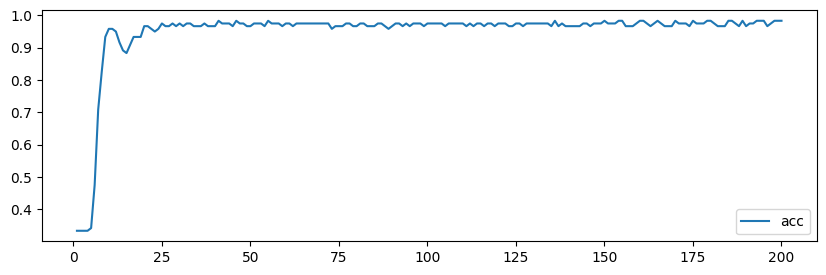

In [ ]:
# 시각화, accuracy
plt.figure(figsize=(10, 3))
plt.plot(range(1, 201), h.history['accuracy'], label='acc')
plt.legend()
plt.show()

In [ ]:
# 답데이터 원핫인코딩 y_train_oh + 'categorical_cross_entropy'
# y_train + 'sparse_categorical_crossentropy'

# 데이터 살펴봤을 때, 답 데이터가 생긴 원본의 형태에 따라 지정
# 원핫인코딩 >> 'categorical_~~'
# 원핫인코딩x >> 'sparse_categorical_~~'

In [ ]:
# 모델 예측
# X_test
pre = model.predict(X_test)
pre

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


array([[9.99942720e-01, 5.71771743e-05, 1.05803091e-08],
       [9.99881685e-01, 1.18272917e-04, 2.28956782e-08],
       [9.99957502e-01, 4.23913261e-05, 3.54257912e-09],
       [9.99882758e-01, 1.17124873e-04, 1.86282101e-08],
       [9.99997318e-01, 2.66082907e-06, 5.89530230e-11],
       [1.17875447e-06, 1.75162622e-05, 9.99981225e-01],
       [1.17960945e-03, 9.85881329e-01, 1.29390731e-02],
       [9.99934852e-01, 6.51218725e-05, 9.48863121e-09],
       [8.65231486e-05, 5.40274847e-03, 9.94510651e-01],
       [1.25298102e-04, 9.99667048e-01, 2.07678764e-04],
       [3.49538546e-04, 9.98671770e-01, 9.78766941e-04],
       [9.99920905e-01, 7.90670601e-05, 2.21828547e-08],
       [4.19516495e-04, 9.98563409e-01, 1.01706199e-03],
       [1.94700225e-03, 9.56772387e-01, 4.12806273e-02],
       [1.43447360e-05, 4.34971997e-04, 9.99550641e-01],
       [9.99985516e-01, 1.44684582e-05, 1.59493219e-09],
       [1.65302970e-03, 4.47218746e-01, 5.51128149e-01],
       [1.38573505e-05, 8.74124

In [ ]:
# 30개의 문제 (행 데이터 = 문제 개수)
# 3개는 각 클래스에 대한 확률 값을 담은 것 (클래스의 개수)
np.argmax(pre[0])

# 지수표기법(float)
# 과학적 표기법: 아주 크거나 작은 값에 대해서 표현하는 방법
# 9.9994272e-01: 0.99786699 * 100 = 99.79
# 확률값이 제일 높은 인덱스 위치는? 0 (예측값)

np.int64(0)

In [ ]:
# pre 전체에 대해서 확률값이 가장 높은 인덱스 출력해보기
# 행방향 데이터
# 열방향 데이터
# 각 X_test에 대한 예측 결과값 확인
pre2 = np.argmax(pre, axis=1)
data.target_names[pre2]

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'virginica',
       'versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'virginica', 'virginica', 'setosa', 'virginica',
       'virginica', 'virginica', 'versicolor', 'setosa', 'virginica',
       'virginica', 'versicolor', 'versicolor', 'versicolor'],
      dtype='<U10')

In [ ]:
X_test[0]

array([4.6, 3.2, 1.4, 0.2])